In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

In [9]:
#Generate a Dataset
X,y = make_regression(n_samples=750,n_features=10,n_informative=5,noise=15, random_state=0)
print(X.shape,y.shape)
n_features = X.shape[1]

(750, 10) (750,)


In [10]:
#Normalise the Data
def Normalise(X):
    u = X.mean(axis=0)
    stddev = X.std(axis=0)
    return (X-u)/stddev

X = Normalise(X)

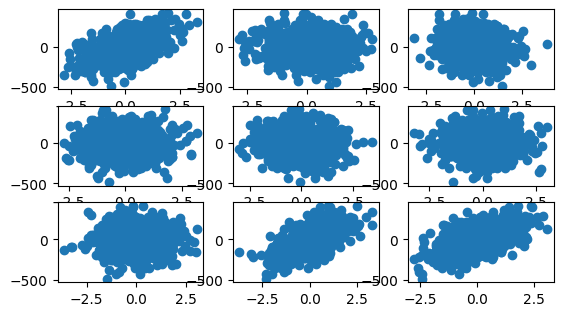

In [11]:
#Visualise the Data
for f in range(0,9):
    plt.subplot(4,3,f+1)
    plt.scatter(X[:,f],y)
plt.show()

In [12]:
#Deciding Testing Split
XT, Xt, yT, yt = train_test_split(X,y,test_size=0.3, random_state=0, shuffle=False)

print("Shape of Xt before preprocess:", Xt.shape)

Shape of Xt before preprocess: (225, 10)


In [13]:
#Modelling
# def Preprocess(X):
#     m = X.shape[0]
#     if np.all(X[:, 0] == 1):
#         return X
#     else:
#         ones = np.ones((m, 1))
#         X = np.hstack((ones, X))
#     return X

# XT = Preprocess(XT)
# Xt = Preprocess(Xt)

def Hypothesis(X,theta):
    return np.dot(X,theta)

def LossFunction(X,y,theta):
    yp = Hypothesis(X,theta)
    m = X.shape[0]
    error = np.mean((yp-y)**2)
    return error

def GradientDescent(X,y,theta):
    yp = Hypothesis(X,theta)
    m = X.shape[0]
    grad = np.dot(X.T, (yp-y))
    return grad/m

def TrainingLoop(X,y,learning_rate = 0.1, max_iterations=100):
    n = X.shape[1]
    theta = np.random.randn(n)
    error_list = []

    for i in range(max_iterations):
        e = LossFunction(X,y,theta)
        error_list.append(e)
        grad = GradientDescent(X,y,theta)
        theta = theta - learning_rate*grad
    
    plt.plot(error_list)
    return theta

[82.90327095  0.11744977 -0.33635553  2.5146253   0.20988428  1.04012057
 -0.80989612 91.97588989 78.29086633 18.69440351]
0.984090116631473


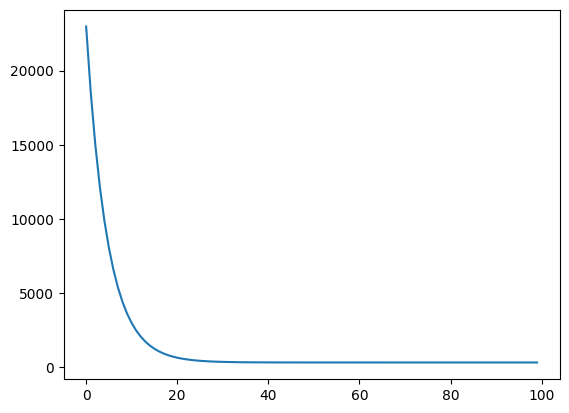

In [14]:
#Evaluation
def R2score(y,yp):
    ymean = y.mean()
    num = np.sum((y-yp)**2)
    denom = np.sum((y-ymean)**2)
    return 1 - (num/denom)



theta = TrainingLoop(XT,yT)
print(theta)

yp = Hypothesis(X,theta)
r2score = R2score(y,yp)
print(r2score)
plt.show()